# MC

This notebook shows how to prgrametically run SWAT with pertubated inputs. It imports from `python_pipeline_scripts`.

## Load environment

In [1]:
import sys; sys.executable

'c:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\.venv\\Scripts\\python.exe'

In [2]:
from pathlib import Path
import sys
# Add project root to sys.path for imports
sys.path.insert(0, str(Path().resolve().parent))
from python_pipeline_scripts import utils, runner
from python_pipeline_scripts.provenance_report import write_provenance_reports

# Load config from config.yaml
config = utils.load_config(Path().resolve().parent / 'config' / 'config.yaml')

# Enable autoreload in Jupyter for live code updates
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "1")
except NameError:
    pass  # Not in IPython/Jupyter


# this is were this notebook is located and from where relative paths will be resolved
import os
os.getcwd()

'c:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\notebooks'

## monte carlo runs

In [3]:
# Ensure verbose logging for raster aggregation (even when cached)
from python_pipeline_scripts import utils
from pathlib import Path

cfg = utils.load_config(Path("../config/config.yaml"))
# Force INFO/DEBUG as you prefer
cfg.setdefault("logging", {})["level"] = "INFO"

# Initialize module loggers with this config BEFORE invoking the functions
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)

# Now your call will emit lines like:
# "Reprojected (cached) -> ..." and "Clipped (cached) -> ..."


<Logger python_pipeline_scripts.transforms.soil_chm (INFO)>

In [4]:
# Input paths (run this cell before your main pipeline cell)

from pathlib import Path
from python_pipeline_scripts.provenance_report import build_upstream_inputs

def _resolve(p: str, base: Path) -> Path:
    pp = Path(p)
    return pp if pp.is_absolute() else (base / pp).resolve()

# ---------- CHM inputs ----------
script_dir = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\script DIFFUSE loads - input .chm")
raster_folder = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters"
hru_zones_fp= r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Archivos de Cesar Ruben Fernandez De Villaran San Juan - swat_cubillas\cubillas_hru\Watershed\Shapes\hru1.shp"
output_gpkg = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Diffuse loads\Soil chemical composition\python calculated hru stats\hru_chem_stats.gpkg"

output_gpkg_p = _resolve(output_gpkg, script_dir)
raster_folder_p = _resolve(raster_folder, script_dir)
zones_fp_p = Path(hru_zones_fp)
manifest_file = Path(str(output_gpkg_p) + ".manifest.json")
chm_csv = str(output_gpkg_p).replace(".gpkg", ".csv")

# ---------- Point loads inputs ----------
point_script_dir = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\script POINT loads - input .dat")
pop_raster_folder = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES\1970-2021 copy"
subbasins_fp = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\SWaT outputs\Cubillas\shapes cubillas\Sub_basin.shp"
pop_output_gpkg = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.gpkg"

pop_raster_folder_p = _resolve(pop_raster_folder, point_script_dir)
#subbasins_fp_p = _resolve(subbasins_fp, point_script_dir)
pop_output_gpkg_p = _resolve(pop_output_gpkg, point_script_dir)
point_csv = Path(str(pop_output_gpkg_p).replace(".gpkg", ".csv"))

# ---------- SWAT base + outputs ----------
base_txtinout = r"C:\SWAT\RSWAT\cubillas\cubillas_set_219_ruben\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1"
realizations_root = r"C:\SWAT\RSWAT\cubillas\mc_realizations"
results_root = r"C:\SWAT\RSWAT\cubillas\mc_results"

base_txtinout_p = Path(base_txtinout)
realizations_root_p = Path(realizations_root); realizations_root_p.mkdir(parents=True, exist_ok=True)
results_root_p = Path(results_root); results_root_p.mkdir(parents=True, exist_ok=True)

# ---------- Upstream inputs for provenance ----------
upstream_chm = build_upstream_inputs(
    raster_folder=raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=zones_fp_p,
    gpkg_path=output_gpkg_p,
    csv_path=Path(chm_csv),
)
upstream_point = [point_csv]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})


# ----------- config ------------------------------

cfg = utils.load_config(Path("../config/config.yaml"))


# ---------- Quick sanity prints ----------
print("repo wide config:", cfg)
print("CHM GPKG:", output_gpkg_p)
print("CHM CSV:", chm_csv)
print("Point GPKG:", pop_output_gpkg_p)
print("Point CSV:", point_csv)
print("Base TxtInOut:", base_txtinout_p)
print("Realizations root:", realizations_root_p)
print("Results root:", results_root_p)
print("Manifest (CHM):", manifest_file)


repo wide config: {'logging': {'level': 'INFO', 'log_dir': 'logs', 'file': 'pipeline.log', 'format': '%(asctime)s | %(levelname)s | %(name)s | %(message)s'}, 'paths': {'project_root': '..', 'data_root': 'data', 'outputs_root': 'outputs', 'base_txtinout': 'C:\\SWAT\\RSWAT\\cubillas\\cubillas_set_219_ruben\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1', 'swat_executable': 'C:\\SWAT\\ArcSWAT\\swat_64rel.exe'}, 'input_groups': {'baseline': {'description': 'Base input data set (recreated)', 'folder': 'C:\\SWAT\\RSWAT\\cubillas\\cubillas_set_219_ruben\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1'}, 'urban_expansion_2030': {'description': 'Urban expansion scenario for 2030', 'folder': 'data/input_groups/urban_expansion_2030'}, 'climate_rcp45': {'description': 'Climate RCP4.5 scenario', 'folder': 'data/input_groups/climate_rcp45'}}, 'reproducibility': {'random_seed': 12345, 'change_sets': [{'name': 'example_change', 'applies_to_group': 'base

## Run input data transformation pipeline (or load from cache)

In [5]:
from pathlib import Path
from typing import List

def find_files_with_string(base_path: str, search_str: str, prefix: str = "", remove_substring: str = "") -> List[str]:
    """
    Look for files in base_path whose names contain search_str.
    Return a list of file names with prefix prepended, and with remove_substring removed from the name if present.

    Parameters
    ----------
    base_path : str
        The path to search in.
    search_str : str
        The substring to look for in file names (case-sensitive).
    prefix : str, optional
        Prefix to prepend to each matching file name.
    remove_substring : str, optional
        Substring to remove from each matching file name before returning.

    Returns
    -------
    List[str]
        List of matching file names with prefix, and with remove_substring removed.
    """
    base = Path(base_path)
    if not base.is_dir():
        raise ValueError(f"{base_path} is not a valid directory")

    matches = []
    for entry in base.iterdir():
        if entry.is_file() and search_str in entry.name:
            name = entry.name
            if remove_substring:
                name = name.replace(remove_substring, "")
            matches.append(prefix + name)

    return matches


path_to_rasters = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters"

P_raster_interpolation = find_files_with_string(path_to_rasters, "P_", "mean_", remove_substring = ".tif")[0]
N_raster_interpolation = find_files_with_string(path_to_rasters, "N_", "mean_", remove_substring = ".tif")[0]
N_raster_interpolation, P_raster_interpolation

('mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample',
 'mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample')

2026-03-20 12:41:12,026 | INFO | notebook.inputs | CHM CSV missing or rebuild=True; running rasterZonalAggregationToGPKG


→ Reading hru shapefile: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Archivos de Cesar Ruben Fernandez De Villaran San Juan - swat_cubillas\cubillas_hru\Watershed\Shapes\hru1.shp
✔ Filtered valid hrus: 878 features retained where `HRU_GIS` is not null, empty, or 'NA'.
✔ Reprojected hrus to EPSG:25830
→ Using bounding box for clipping: [ 438912.5        4123462.50012207  470812.5        4158362.50012207]
→ Found 2 raster file(s) matching pattern (case-insensitive)

🔹 Processing raster: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters\N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif → alias: N_prediction_best_according_weight_bias_accuracy_wc_error_resample
→ Raster stats BEFORE clip:
   MIN: 0.04749999940395355, MAX: 1.7711111307144165, MEAN: 0.22466200590133667, SUM: 14852589.0
→ Raster stats AFTER clip:
   MIN: 0.07374999672174454, MAX: 0.496250003576

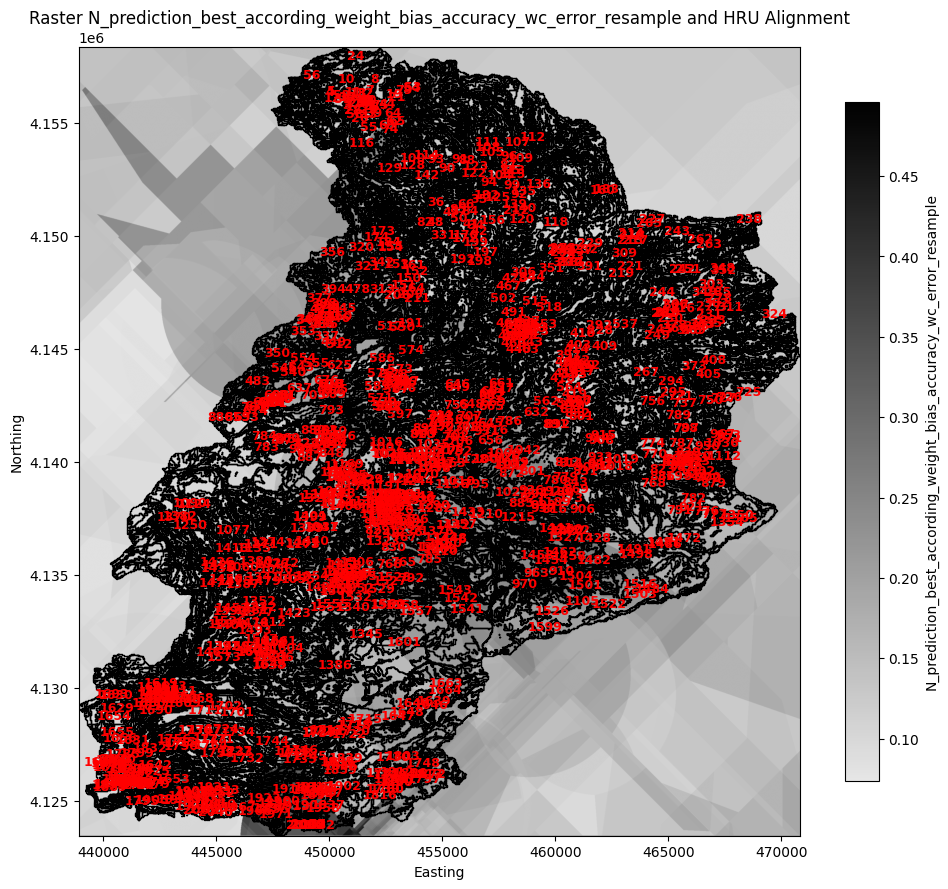

✔ Zonal statistics for mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample:
   HRU 000010061: mean=0.1449578011390006, COUNT=2020, AVG=7.176128769257456e-05
   HRU 000010064: mean=0.13446803669353108, COUNT=910, AVG=0.0001477670732895946
   HRU 000010063: mean=0.13281639099121093, COUNT=350, AVG=0.00037947540283203124
   HRU 000010081: mean=0.13605503142437683, COUNT=3741, AVG=3.6368626416566914e-05
   HRU 000010062: mean=0.14770112586788725, COUNT=2579, AVG=5.7270696342724793e-05
   HRU 000010093: mean=0.1502078978483342, COUNT=3872, AVG=3.879336204760697e-05
   HRU 000010094: mean=0.14854134858039414, COUNT=10377, AVG=1.4314478999748881e-05
   HRU 000010085: mean=0.14298169178523132, COUNT=17378, AVG=8.227741499898223e-06
   HRU 000010082: mean=0.14246861851630518, COUNT=4824, AVG=2.9533295712335237e-05
   HRU 000010100: mean=0.1350346061581925, COUNT=2204, AVG=6.126797012622163e-05
   HRU 000010083: mean=0.13138778440413937, COUNT=620, AVG=0.000211915781296999
  

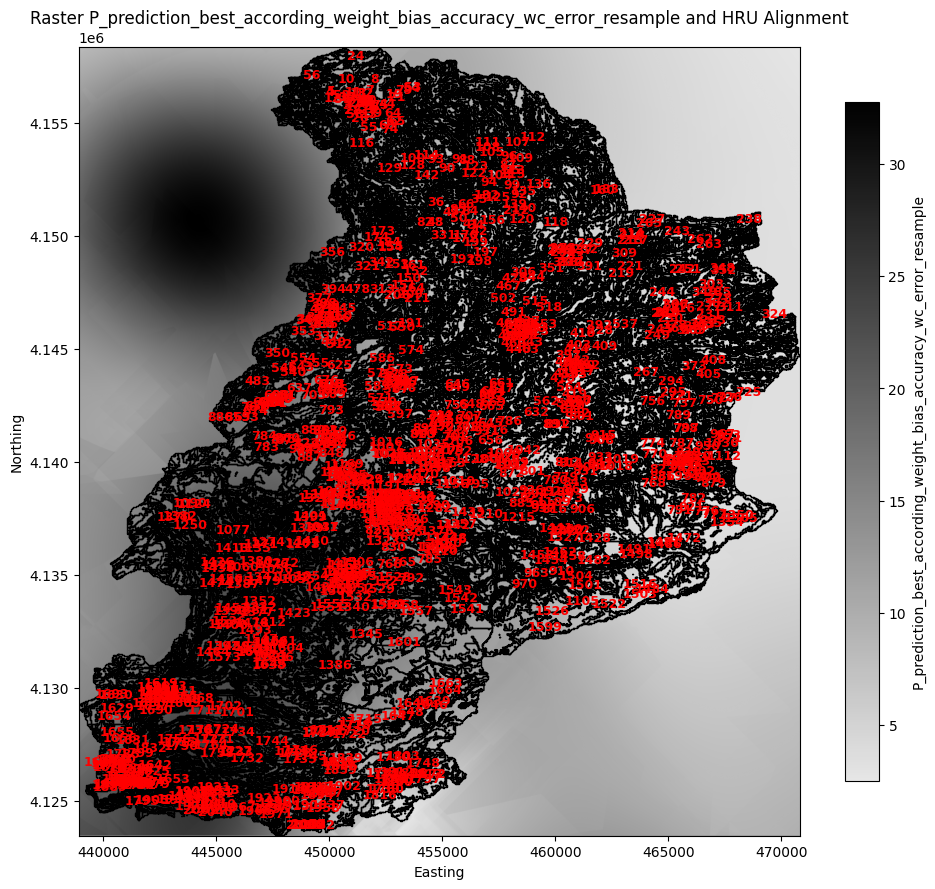

✔ Zonal statistics for mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample:
   HRU 000010061: mean=11.165819345606435, COUNT=2020, AVG=0.005527633339409126
   HRU 000010064: mean=12.08623798076923, COUNT=910, AVG=0.013281580198647506
   HRU 000010063: mean=12.006792689732142, COUNT=350, AVG=0.034305121970663266
   HRU 000010081: mean=12.118338178294573, COUNT=3741, AVG=0.003239331242527285
   HRU 000010062: mean=11.033852904468786, COUNT=2579, AVG=0.0042783454457032905
   HRU 000010093: mean=11.243531282283058, COUNT=3872, AVG=0.0029038045667053353
   HRU 000010094: mean=10.727861195432206, COUNT=10377, AVG=0.0010338114286819126
   HRU 000010085: mean=11.271129445275635, COUNT=17378, AVG=0.0006485861114786302
   HRU 000010082: mean=11.180979056540215, COUNT=4824, AVG=0.0023177817281385188
   HRU 000010100: mean=11.15069015142922, COUNT=2204, AVG=0.005059296801918884
   HRU 000010083: mean=12.435127898185485, COUNT=620, AVG=0.02005665790029917
   HRU 000010086: mean=

2026-03-20 12:43:19,774 | INFO | notebook.inputs | CHM CSV ready: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Diffuse loads\Soil chemical composition\python calculated hru stats\hru_chem_stats.csv


✔ Done
→ Reading sub-basin shapefile: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\SWaT outputs\Cubillas\shapes cubillas\Sub_basin.shp
✔ Reprojected sub-basins to EPSG:25830
→ Using bounding box for clipping: [ 438912.5        4123462.50012207  470812.5        4158362.50012207]

→ Writing results to GeoPackage: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.gpkg (layer: population_by_subbasin)
✔ Done
Exported to CSV: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.csv


C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\python_pipeline_scripts\TEMP_point_dat_insparation.py:414: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  result_wide[numeric_cols] = result_wide[numeric_cols].applymap(lambda x: int(float(x)))


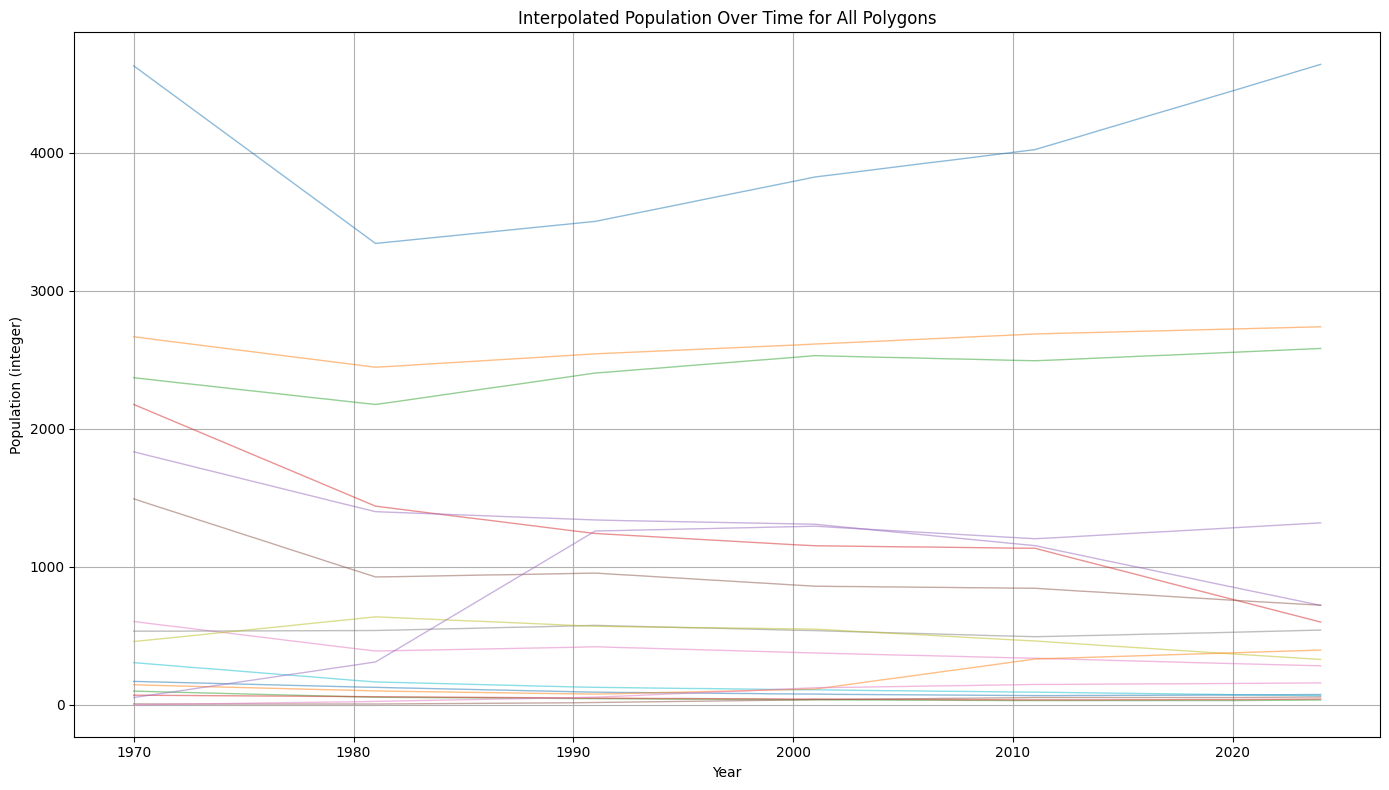

10.35
start_year = 1981 
end_year   = 2020
Columns in expected_mgL_values: {'ORGNYR', 'DISOXYR', 'CHLAYR', 'CBODYR', 'ORGPYR', 'MINPYR', 'NO2YR', 'NO3YR', 'NH3YR', 'SEDYR'}
Requested final columns: {'BACTPYR', 'CHLAYR', 'BACTLPYR', 'CMTL1YR', 'FLOYR', 'YEAR', 'NO3YR', 'DISOXYR', 'CBODYR', 'SRBPSTYR', 'ORGPYR', 'NO2YR', 'SOLPSTYR', 'NH3YR', 'SEDYR', 'ORGNYR', 'CMTL2YR', 'MINPYR', 'CMTL3YR'}
Intersection (will be filled): {'ORGNYR', 'DISOXYR', 'CHLAYR', 'CBODYR', 'ORGPYR', 'MINPYR', 'NO2YR', 'NO3YR', 'NH3YR', 'SEDYR'}
Missing in expected_mgL_values (will be filled with 0): {'BACTPYR', 'BACTLPYR', 'SRBPSTYR', 'CMTL2YR', 'CMTL3YR', 'SOLPSTYR', 'CMTL1YR'}
Extra in expected_mgL_values (not requested): set()
Columns in expected_mgL_values: {'ORGNYR', 'DISOXYR', 'CHLAYR', 'CBODYR', 'ORGPYR', 'MINPYR', 'NO2YR', 'NO3YR', 'NH3YR', 'SEDYR'}
Requested final columns: {'BACTPYR', 'CHLAYR', 'BACTLPYR', 'CMTL1YR', 'FLOYR', 'YEAR', 'NO3YR', 'DISOXYR', 'CBODYR', 'SRBPSTYR', 'ORGPYR', 'NO2YR', 'SOLPSTYR',

2026-03-20 12:43:21,909 | INFO | notebook.inputs | Point CSV missing or rebuild=True; building population GPKG/CSV


✅ File saved: .\swat_ready_recyear_files\rcyr_17.dat
→ Reading sub-basin shapefile: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\SWaT outputs\Cubillas\shapes cubillas\Sub_basin.shp
✔ Reprojected sub-basins to EPSG:25830
→ Using bounding box for clipping: [ 438912.5        4123462.50012207  470812.5        4158362.50012207]

→ Writing results to GeoPackage: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.gpkg (layer: population_by_subbasin)


2026-03-20 12:43:22,186 | INFO | notebook.inputs | Point CSV ready: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.csv


✔ Done


In [6]:
# Inputs + aggregator with rebuild flags (CHM + Point); logs all decisions.
from pathlib import Path
from python_pipeline_scripts import utils
from python_pipeline_scripts.raster_agg import  rasterZonalAggregationToGPKG
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import build_upstream_inputs

# Flags: set True to force (re)create CSVs; set False to use cached CSVs if present
REBUILD_CHM_CSV = True
REBUILD_POINT_CSV = True

# Ensure module loggers are initialized with your config so cached actions are printed
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)
log = utils.get_logger("notebook.inputs", config=cfg)

def ensure_chm_csv(*, chm_csv: str, raster_folder_p: Path, zones_fp_p: Path, output_gpkg_p: Path, rebuild: bool):
    chm_csv_p = Path(chm_csv)
    if rebuild or not chm_csv_p.exists():
        log.info("CHM CSV missing or rebuild=True; running rasterZonalAggregationToGPKG")
        _ = rasterZonalAggregationToGPKG( #raster_zonal_aggregation_to_gpkg_and_csv(   #raster_zonal_aggregation_to_gpkg(
            raster_folder=raster_folder_p,
            zones_fp=zones_fp_p,
            zone_field="HRU_GIS",
            label_field="OBJECTID",
            output_gpkg=output_gpkg_p,
            files_end_with="_resample.tif",
            stat_operation="mean",
            raster_alias="full_name",
            zone_meaning="HRU",
            overwrite_cache=rebuild,
            #write_manifest=True,
            #config=cfg,
        )
        log.info("CHM CSV ready: %s", chm_csv_p)
    else:
        log.info("Using cached CHM CSV: %s", chm_csv_p)
    return chm_csv_p

def ensure_point_csv(*, point_csv: Path, pop_raster_folder_p: Path, subbasins_fp: Path, pop_output_gpkg_p: Path, rebuild: bool):
    if rebuild or not point_csv.exists():
        try:
            from python_pipeline_scripts.TEMP_point_dat_insparation import subbasinPopulationAggregationToGPKG
            log.info("Point CSV missing or rebuild=True; building population GPKG/CSV")
            _ = subbasinPopulationAggregationToGPKG(
                raster_folder=str(pop_raster_folder_p),
                sub_basin_fp=str(subbasins_fp),
                zone_field="GRIDCODE",
                output_gpkg=str(pop_output_gpkg_p),
                overwrite_cache=rebuild,
            )
            if not point_csv.exists():
                raise FileNotFoundError(f"Builder ran but CSV still missing: {point_csv}")
            log.info("Point CSV ready: %s", point_csv)
        except Exception as e:
            log.error("Failed to build point CSV automatically: %s", e)
            raise
    else:
        log.info("Using cached Point CSV: %s", point_csv)
    return point_csv

# Ensure CSVs exist (or rebuild if flags set)
chm_csv_p = ensure_chm_csv(
    chm_csv=chm_csv,
    raster_folder_p=raster_folder_p,
    zones_fp_p=zones_fp_p,
    output_gpkg_p=output_gpkg_p,
    rebuild=REBUILD_CHM_CSV,
)
point_csv_p = ensure_point_csv(
    point_csv=point_csv,
    pop_raster_folder_p=pop_raster_folder_p,
    subbasins_fp=subbasins_fp,
    pop_output_gpkg_p=pop_output_gpkg_p,
    rebuild=REBUILD_POINT_CSV,
)

# Upstream inputs for provenance
upstream_chm = build_upstream_inputs(
    raster_folder=raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=zones_fp_p,
    gpkg_path=output_gpkg_p,
    csv_path=chm_csv_p,
)
upstream_point = [point_csv_p]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})

# Aggregator: logs will show if cached/rebuilt
aggregator = lambda: {
    "chm": read_n_p_means_from_csv_to_df(
        str(chm_csv_p),
        id_col="HRU_GIS",
        n_col=N_raster_interpolation,
        #n_col="N_prediction_best_according_weight_bias_accuracy_wc_error_resample",
        p_col=P_raster_interpolation,
    ),
    "point": normalize_point_year_columns(
        read_population_by_subbasin_csv_to_df(point_csv_p, id_col="GRIDCODE", sep=";"),
        id_col="GRIDCODE",
        debug=False,
    ),
}


In [7]:

from python_pipeline_scripts.transforms.soil_chm import derive_global_uncertainty

UNCERTAINTY_METHOD = "rmse_rel_center" # "rmse_rel_center",  # "csv_p90_absolute_relative_error", "csv_half_width_relative_error", "csv_p90_absolute_relative_error", csv_mean_relative_error, csv_mean_absolute_relative_error, csv_median_relative_error, csv_p75_relative_error, csv_p75_absolute_relative_error

N_pred = path_to_rasters + "/" + find_files_with_string(path_to_rasters, "N_", "")[0]
N_se = path_to_rasters + "/standard error/" + find_files_with_string(path_to_rasters, "N_", "se_")[0]
N_cv_csv = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"

# Use the cross-validation CSV to derive a relative uncertainty band for N
out_n = derive_global_uncertainty(
    prediction=N_pred,
    se=N_se,
    method=UNCERTAINTY_METHOD,
    csv_path=N_cv_csv,
    csv_filter_zeros=True,
)

P_pred = path_to_rasters + "/" + find_files_with_string(path_to_rasters, "P_", "")[0]
P_se = path_to_rasters + "/standard error/" + find_files_with_string(path_to_rasters, "P_", "se_")[0]
P_cv_csv = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# Use the cross-validation CSV to derive a relative uncertainty band for P
out_p = derive_global_uncertainty(
    prediction=P_pred,
    se=P_se,
    method=UNCERTAINTY_METHOD,
    csv_path=P_cv_csv,
    csv_filter_zeros=True,
)

print("\nN lower factor:  ", out_n["lower_factor"], "\nN half width rel:", out_n["half_width_rel"], "\nN upper factor:  ", out_n["upper_factor"], "\n\nP lower factor:  ", out_p["lower_factor"], "\nP half width rel:", out_p["half_width_rel"], "\nP upper factor:  ", out_p["upper_factor"])   # {'half_width_rel': ..., 'lower_factor': ..., 'upper_factor': ...

2026-03-20 12:43:30,940 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=rmse_rel_center | sources=['prediction: C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\Genil_ArcGIS_Ruben\\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\\raster\\temp_rasters\\N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif', 'standard error: C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\Genil_ArcGIS_Ruben\\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\\raster\\temp_rasters\\standard error\\se_N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif']


Method used: rmse_rel_center
How it was calculated: sqrt(mean(SE^2)) divided by mean(abs(center)) using the raster prediction and SE inputs.
Source dataset: prediction raster + standard error raster
Source path: prediction: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters\N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif
Source path: standard error: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters\standard error\se_N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif


2026-03-20 12:43:38,988 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=rmse_rel_center | sources=['prediction: C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\Genil_ArcGIS_Ruben\\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\\raster\\temp_rasters\\P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif', 'standard error: C:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\Genil_ArcGIS_Ruben\\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\\raster\\temp_rasters\\standard error\\se_P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif']


Method used: rmse_rel_center
How it was calculated: sqrt(mean(SE^2)) divided by mean(abs(center)) using the raster prediction and SE inputs.
Source dataset: prediction raster + standard error raster
Source path: prediction: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters\P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif
Source path: standard error: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters\standard error\se_P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif

N lower factor:   0.1998993718520402 
N half width rel: 0.8001006281479598 
N upper factor:   1.80010062814796 

P lower factor:   0.4191840739192514 
P half width rel: 0.5808159260807486 
P upper factor:   1.5808159260807486


In [8]:
import pandas as pd
import numpy as np
from pathlib import Path

def calculate_uncertainty_measures(csv_path, value_col='Measured', pred_col='Predicted', 
                                   filter_zeros=True, epsilon=1e-10):
    """
    Calculate global uncertainty measures from leave-one-out cross-validation CSV.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing measured and predicted values.
    value_col : str
        Column name for observed values (default: 'Measured').
    pred_col : str
        Column name for predicted values (default: 'Predicted').
    filter_zeros : bool
        If True, remove rows where observed value is 0 (default: True).
    epsilon : float
        Small value to avoid division by zero in relative error calculation.

    Returns
    -------
    dict
        Dictionary with global uncertainty metrics.
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Optionally remove rows where measured = 0
    if filter_zeros:
        df = df[df[value_col] != 0].copy()
    
    if df.empty:
        raise ValueError("No valid rows remain after filtering zeros.")
    
    # Compute relative errors (relative to measured value)
    rel_error = (df[pred_col] - df[value_col]) / (df[value_col] + epsilon)
    abs_rel_error = np.abs(rel_error)
    
    # Compute RMSE-based metrics
    rmse = np.sqrt(np.mean((df[pred_col] - df[value_col])**2))
    obs_range = df[value_col].max() - df[value_col].min()
    obs_mean = df[value_col].mean()
    
    # Compute standard metrics
    metrics = {}
    metrics['File_Name'] = Path(csv_path).name
    
    metrics['RMSE'] = rmse
    metrics['NRMSE_Range'] = rmse / obs_range if abs(obs_range) > epsilon else np.nan
    metrics['NRMSE_Mean'] = rmse / obs_mean if abs(obs_mean) > epsilon else np.nan
    metrics['Mean_Relative_Error'] = np.mean(rel_error)
    metrics['Mean_Absolute_Relative_Error'] = np.mean(abs_rel_error)
    metrics['Median_Relative_Error'] = np.median(rel_error)
    metrics['Median_Absolute_Relative_Error'] = np.median(abs_rel_error)
    
    metrics['P75_Relative_Error'] = np.percentile(rel_error, 75)
    metrics['P75_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 75)
    
    metrics['P90_Relative_Error'] = np.percentile(rel_error, 90)
    metrics['P90_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 90)
    metrics['Std_Relative_Error'] = np.std(rel_error)
    metrics['Count'] = len(df)
    metrics['Trailing_New_Line'] = "\n"
    
    return metrics

# ------------------------------
# Example usage:


def print_uncertainty_results(results):
    for k, v in results.items():
        if k == 'Trailing_New_Line':
            print(v, end="")
        elif isinstance(v, str):
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")


# original P REDIAM interpolation
csv_file_2_point_5 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_2_point_5, filter_zeros=True)
print_uncertainty_results(results)


# first wrong P REDIAM + LUCAS interpolation
csv_file_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_2, filter_zeros=True)
print_uncertainty_results(results)

# second correctly harmonized P REDIAM + LUCAS interpolation
csv_file_2_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\P_LUCA~2.CSV"  # harmonized version
results = calculate_uncertainty_measures(csv_file_2_point_2, filter_zeros=True)
print_uncertainty_results(results)


# original N REDIAM interpolation
csv_file_1_point_5 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_1_point_5, filter_zeros=True)
print_uncertainty_results(results)

# first wrong N REDIAM + LUCAS interpolation
csv_file_1 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_1, filter_zeros=True)
print_uncertainty_results(results)

# second correctly harmonized N REDIAM + LUCAS interpolation
csv_file_1_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\N_LUCA~2.CSV"  # harmonized version
results = calculate_uncertainty_measures(csv_file_1_point_2, filter_zeros=True)
print_uncertainty_results(results)



File_Name: P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 28.6732
NRMSE_Range: 0.1491
NRMSE_Mean: 1.0040
Mean_Relative_Error: 24.8744
Mean_Absolute_Relative_Error: 25.2558
Median_Relative_Error: 0.2588
Median_Absolute_Relative_Error: 0.6465
P75_Relative_Error: 2.0311
P75_Absolute_Relative_Error: 2.0311
P90_Relative_Error: 6.7219
P90_Absolute_Relative_Error: 6.7219
Std_Relative_Error: 166.2357
Count: 255.0000

File_Name: P_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 115.9714
NRMSE_Range: 0.1384
NRMSE_Mean: 1.2204
Mean_Relative_Error: 2.6327
Mean_Absolute_Relative_Error: 2.9920
Median_Relative_Error: 0.5446
Median_Absolute_Relative_Error: 0.8047
P75_Relative_Error: 2.8738
P75_Absolute_Relative_Error: 2.8738
P90_Relative_Error: 8.1730
P90_Absolute_Relative_Error: 8.1730
Std_Relative_Error: 5.7446
Count: 351.0000

File_Name: P_LUCA~2.CSV
RMSE: 26.3827
NRMSE_Range: 0.1372
NRMSE_Mean: 1.2352
Mean_Relative_Error: 13.9448
Mean_Ab

In [10]:
from pathlib import Path
from python_pipeline_scripts.spec_runner import run_from_spec
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import summarize_run, realization_report, build_upstream_inputs


# MC_SPEC: declare data and their transforms towards SWAT input formats as well as and upper/lower uncertainty bounds, choose a mode
MC_SPEC = {
    "mode": "minmax",  # 'mean' | 'random' | 'extreme' | 'minmax'
    "draws": 10,        # only used when mode == 'random'
    "debug": True,

    "transforms": [
        # CHM: compute base (deterministic)
        {"type": "ops", "target": "chm", "name": "compute_base_ops", "ops": [
            {"src": N_raster_interpolation, "out": "N_total_mg_kg", "op": "mul",  #in this case, the input is in % of dry weight, so we multiply by 10,000 to get mg/kg (assuming soil bulk density and moisture content are not considered here)
            "factor": 0 * 10_000.0, "lower": 0 * 10_000.0 * out_n["lower_factor"], "upper": 0 * 10_000.0 * out_n["upper_factor"]}, # 10,000 to convert % to mg/kg
            {"src": P_raster_interpolation, "out": "P_element_mg_kg", "op": "mul",
            "factor": 0 * 10.0 * 0.4364, "lower": (0 * 10.0 * 0.4364) * out_p["lower_factor"], "upper": (0 * 10.0 * 0.4364) * out_p["upper_factor"]}, # 10 to convert from mg/100g to mg/kg, 0.4364 to convert P2O5 to P
        ]},



        # CHM: split N pool (bounded)
        {"type": "split", "target": "chm", "src": "N_total_mg_kg", "renormalize": True,
         "outputs": [
             {"name": "Soil NO3 [mg/kg]",       "standard": 0.02, "lower": 0.015, "upper": 0.03},
             {"name": "Soil organic N [mg/kg]", "standard": 0.98, "lower": 0.95, "upper": 0.99},
        ]},
        # CHM: derive TN, Norg, and NO3 from TKN
        # {"type": "ops", "target": "chm", "name": "derive_n_pools_from_tkn", "ops": [
        #     {"src": "N_total_mg_kg", "out": "TN_total_mg_kg", "op": "mul",
        #     "standard": 1.0 / 0.97, "lower": 1.0 / 0.97, "upper": 1.0 / 0.97},
        #     {"src": "N_total_mg_kg", "out": "Soil organic N [mg/kg]", "op": "mul",
        #     "standard": 1.0, "lower": 1.0, "upper": 1.0},
        #     {"src": "TN_total_mg_kg", "out": "Soil NO3 [mg/kg]", "op": "mul",
        #     "standard": 0.03, "lower": 0.03, "upper": 0.03},
        # ]},



          

        # CHM: derive P_org from N (bounded)
        {"type": "ops", "target": "chm", "name": "derive_p_org_from_n", "ops": [
            {"src": "N_total_mg_kg", "out": "Soil organic P [mg/kg]", "op": "mul",
             "standard": 0.125, "lower": 0.07, "upper": 0.2},
             #"standard": 0, "lower": 0, "upper": 0},
        ]},

  
        # CHM: split P pool (fixed)
        {"type": "split", "target": "chm", "src": "P_element_mg_kg", "renormalize": False,
         "outputs": [
             {"name": "Soil labile P [mg/kg]", "standard": 2, "lower": 1, "upper": 5},
             #{"name": "Soil labile P [mg/kg]", "standard": 0, "lower": 0, "upper": 0},
        ]},

        ### Set fixed values for P pools (just a test to recreat original BASE POINT SET-219)
        #{"type": "ops", "target": "chm", "name": "set_labile_p_fixed", "ops": [
        #{"out": "Soil labile P [mg/kg]", "op": "set", "value": 5.0, "mean": 5.0, "lower": 5.0, "upper": 5.0, "source": "fixed"}
        #]},

        # CHM: write CHM files
        {"type": "write_chm", "target": "chm", "id_col": "HRU_GIS",
         "label_map": {
             "Soil NO3 [mg/kg]":     "Soil NO3 [mg/kg]",
             "Soil organic N [mg/kg]": "Soil organic N [mg/kg]",
             "Soil labile P [mg/kg]":  "Soil labile P [mg/kg]",
             "Soil organic P [mg/kg]": "Soil organic P [mg/kg]",
        }},



        # POINT: interpolate from decade to yearly (1981-2020)
        {"type": "interpolate_years_wide", "target": "point", "id_col": "GRIDCODE", "year_start": 1981, "year_end": 2020},

        # POINT: compute timeseries from population and mg/L specs (bounded)
        {"type": "build_point", "target": "point", "id_col": "GRIDCODE", 

        "wastewater_lppd": {"standard": 250,  "lower": 100,  "upper": 400},
         "mgL_values": {
             "ORGNYR": {"standard": 15,     "lower": 8,   "upper": 35   },
             "ORGPYR": {"standard": 3,      "lower": 1,   "upper": 5    },
             "NO3YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "NH3YR":  {"standard": 25,     "lower": 12,  "upper": 50   },
             "NO2YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "MINPYR": {"standard": 5,      "lower": 3,   "upper": 10   },
             "SEDYR":  {"standard": 720,    "lower": 350, "upper": 1200 },
             "CBODYR": {"standard": 220,    "lower": 110, "upper": 400  },
             "DISOXYR":{"standard": 1,      "lower": 0,   "upper": 2    },
             "CHLAYR": {"standard": 0.001,  "lower": 0.0, "upper": 0.002},

            # JUST to satisfy SWAT input requirements, which needs all columns to be present:
             "SOLPSTYR": {"standard": 0,      "lower": 0,   "upper": 0    },       
             "SRBPSTYR": {"standard": 0,      "lower": 0,   "upper": 0    },
             "BACTPYR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "BACTLPYR": {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL1YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL2YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL3YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
         },
         "out_columns": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"]},

        # POINT: write rcyr_*.dat
        {"type": "write_point_dat", "target": "point", "id_col": "GRIDCODE",
         "columns_order": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"],
         "start_year": 1981, "end_year": 2020},
    ]
}




results = run_from_spec(
    spec=MC_SPEC,
    aggregator=aggregator,
    base_txtinout=base_txtinout_p,
    realization_root=realizations_root_p,
    results_root=results_root_p,
    link_file_regexes=[r"^[0-9]+\.chm$", r"^rcyr_.*\.dat$"],
    outputs_to_copy=["output.std", "*.rch", "output.sub", "file.cio"] ,
    config=cfg,
    manifest_file=Path(str(output_gpkg_p) + ".manifest.json"),
    run_model=True,
    upstream_inputs=[Path(chm_csv), Path(point_csv)],
)

ok = sum(1 for r in results if r.success)
run_id = results[0].run_id if results else -1
print(f"Created {len(results)} realizations; {ok} succeeded. run_id={run_id}")
for r in results:
    print(f"- {r.name}: id={r.realization_id} run_id={r.run_id} success={r.success} folder={r.folder}")

print("\n=== Monte Carlo run summary ===")
print(summarize_run(run_id))

if results:
    print(f"\n=== Single realization report (id={results[0].realization_id}) ===")
    print(realization_report(results[0].realization_id))


2026-03-20 12:48:53,233 | INFO | python_pipeline_scripts.mc_engine | MC start | N=2 | seed=0
2026-03-20 12:48:53,250 | INFO | python_pipeline_scripts.transforms.soil_chm | Loaded HRU CSV: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Diffuse loads\Soil chemical composition\python calculated hru stats\hru_chem_stats.csv | rows=878
2026-03-20 12:48:53,258 | INFO | python_pipeline_scripts.transforms.point_dat | Loaded subbasin CSV: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.csv | rows=17


2026-03-20 12:48:53,327 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample -> N_total_mg_kg | value=0.0 | mean=None lower=0.0 upper=0.0
2026-03-20 12:48:53,329 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample -> P_element_mg_kg | value=0.0 | mean=None lower=0.0 upper=0.0
2026-03-20 12:48:53,333 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] split N_total_mg_kg -> Soil NO3 [mg/kg] | ratio=0.015544 (mean=0.02 lower=0.015 upper=0.03) renorm=True
2026-03-20 12:48:53,338 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] split N_total_mg_kg -> Soil organic N [mg/kg] | ratio=0.984456 (mean=0.98 lower=0.95 upper=0.99) renorm=True
2026-03-20 12:48:53,342 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: N_total_mg_kg -> Soil organic P [mg/kg] | value=0.07 | mean=

[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] Total inhabitants across all subbasins (source years):
  year 1970: 17,607
  year 1981: 14,135
  year 1991: 15,264
  year 2001: 15,578
  year 2011: 15,581
[point] Total inhabitants across all subbasins (interpolated years):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
[point] Total inhabitants across all subbasins (from timeseries input):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370


2026-03-20 12:48:57,333 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample -> N_total_mg_kg | value=0.0 | mean=None lower=0.0 upper=0.0
2026-03-20 12:48:57,336 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample -> P_element_mg_kg | value=0.0 | mean=None lower=0.0 upper=0.0
2026-03-20 12:48:57,339 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] split N_total_mg_kg -> Soil NO3 [mg/kg] | ratio=0.029412 (mean=0.02 lower=0.015 upper=0.03) renorm=True
2026-03-20 12:48:57,340 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] split N_total_mg_kg -> Soil organic N [mg/kg] | ratio=0.970588 (mean=0.98 lower=0.95 upper=0.99) renorm=True
2026-03-20 12:48:57,343 | INFO | python_pipeline_scripts.transforms.soil_chm | [debug] op mul: N_total_mg_kg -> Soil organic P [mg/kg] | value=0.2 | mean=N

[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] normalized years found: [1970, 1981, 1991, 2001, 2011, 2021]
[point] Total inhabitants across all subbasins (source years):
  year 1970: 17,607
  year 1981: 14,135
  year 1991: 15,264
  year 2001: 15,578
  year 2011: 15,581
[point] Total inhabitants across all subbasins (interpolated years):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370
[point] Total inhabitants across all subbasins (from timeseries input):
  year 1981: 14,135
  year 1982: 14,248
  year 1983: 14,361
  year 1984: 14,474
  year 1985: 14,587
  …
  year 2016: 15,464
  year 2017: 15,440
  year 2018: 15,416
  year 2019: 15,393
  year 2020: 15,370


2026-03-20 12:49:00,675 | INFO | python_pipeline_scripts.realizations | Removing existing workspace to recreate: C:\SWAT\RSWAT\cubillas\cubillas_set_219_ruben\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1_work\TxtInOut
2026-03-20 12:49:04,122 | INFO | python_pipeline_scripts.realizations | Creating full workspace copy at C:\SWAT\RSWAT\cubillas\cubillas_set_219_ruben\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1_work\TxtInOut
2026-03-20 12:49:43,945 | INFO | python_pipeline_scripts.realizations | === Realization 'run000199_real000600_1' start | folder=C:\SWAT\RSWAT\cubillas\mc_realizations\run000199_real000600_1 ===
2026-03-20 12:49:43,956 | INFO | python_pipeline_scripts.realizations | Linked (hardlink): 000010001.chm -> C:\SWAT\RSWAT\cubillas\mc_realizations\run000199_real000600_1\000010001.chm
2026-03-20 12:49:43,960 | INFO | python_pipeline_scripts.realizations | Linked (hardlink): 000010002.chm -> C:\SWAT\RSWAT\cubillas\mc_realizations\

Created 2 realizations; 2 succeeded. run_id=199
- run000199_real000600_1: id=600 run_id=199 success=True folder=C:\SWAT\RSWAT\cubillas\mc_realizations\run000199_real000600_1
- run000199_real000601_2: id=601 run_id=199 success=True folder=C:\SWAT\RSWAT\cubillas\mc_realizations\run000199_real000601_2

=== Monte Carlo run summary ===
Run 199: realizations=2 ids=[600, 601]
Time span: 2026-03-20T11:48:53.304496+00:00 → 2026-03-20T11:48:57.316489+00:00
Names:
  - run000199_real000600_1
  - run000199_real000601_2
Transforms:
  - transform_init_copy
  - fn
  - ops_choices
  - split_choices
  - transform_interpolate_years_wide
  - point_mgL_choices
Inputs (union):
  - C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Archivos de Cesar Ruben Fernandez De Villaran San Juan - swat_cubillas\cubillas_hru\Watershed\Shapes\hru1.shp
Perturbations:
  - N_total_mg_kg: bounds=[0.0..0.0] strategy=n/a
  - P_element_mg_kg: bounds=[0.0..0.0] strategy=n/a
  - Soil organic P [mg/kg]: bounds=[0.07..0.2] strategy

In [ ]:
#write_provenance_reports(results)

NameError: name 'results' is not defined